# Collinearity

### Topic Review

Collinearity is a statistical condition in which two independent variables (variables $X$) in a regression model have a very strong linear relationship with each other.

Simply put, our variables overlap excessively. This confuses the model in determining which variables are truly influential, making the resulting coefficients unreliable as a single measure of influence.

why we should avoid collinearity (multicollinearity):
- Parameter Estimation Becomes Unstable
- Loss of Statistical Significance
- Blurring Interpretation (The "Overlap" Effect)
- Overfitting


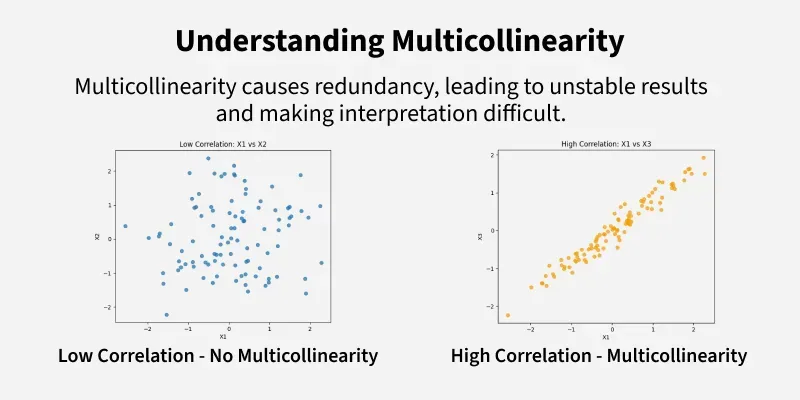

[source](https://www.geeksforgeeks.org/machine-learning/multicollinearity-in-data/)

## Case - Electricity Usage

In this case study, I implemented an electrical regression model to analyze the use of temperature variables and other independent variables that have near collinearity  with the temperature.

In [57]:
# load data
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# modelling
import statsmodels.formula.api as smf

In [58]:
def print_coef_std_err(results):
    """
    Function to combine estimated coefficients and standard error in one DataFrame
    :param results: <statsmodels RegressionResultsWrapper> OLS regression results from 
    :return df: <pandas DataFrame> 
    """
    coef = results.params
    std_err = results.bse

    df = pd.DataFrame(data = np.transpose([coef, std_err]),
                      index = coef.index,
                      columns = ['coef', 'std err'])
    
    return df

In [59]:
electricity = pd.read_csv('household_electricity_usage.csv')
electricity.head()

,Date,Hour,Season,Temperature(°C),Humidity(%),Dew Point(°C),Solar Radiation(MJ/m2),Residents,AC Usage(hours),Heater Usage(hours),Holiday,Functioning Day,Electricity Usage(kWh)
0,2022-01-01,0,Autumn,27.9,60.1,25.7,5.39,2,3.2,2.2,No Holiday,Yes,42.5
1,2022-01-01,1,Winter,20.3,56.3,18.2,4.04,3,4.1,1.8,Holiday,No,42.8
2,2022-01-01,2,Spring,28.9,51.5,27.7,4.92,3,2.5,0.8,No Holiday,Yes,44.1
3,2022-01-01,3,Autumn,30.1,51.8,28.5,4.87,2,8.7,2.7,No Holiday,Yes,58.7
4,2022-01-01,4,Autumn,29.8,54.1,26.4,5.32,4,7.8,1.8,No Holiday,Yes,51.6


- Use LabelEncoder to convert variables into numeric.

In [60]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder Object and transform variables
electricity['Holiday'] = LabelEncoder().fit_transform(electricity['Holiday'])
electricity['Functioning Day'] = LabelEncoder().fit_transform(electricity['Functioning Day'])

In [61]:
electricity.columns

Index(['Date', 'Hour', 'Season', 'Temperature(°C)', 'Humidity(%)',
       'Dew Point(°C)', 'Solar Radiation(MJ/m2)', 'Residents',
       'AC Usage(hours)', 'Heater Usage(hours)', 'Holiday', 'Functioning Day',
       'Electricity Usage(kWh)'],
      dtype='object')

In [62]:
col = ['Hour', 'Temperature(°C)', 'Humidity(%)', 'Dew Point(°C)',
       'Solar Radiation(MJ/m2)', 'Residents', 'AC Usage(hours)', 'Heater Usage(hours)',
       'Holiday', 'Functioning Day', 'Electricity Usage(kWh)']

- Creating a heatmap to check collinearity (multicollinearity) aims to visualize the correlation between predictor variables in a statistical model.
- some of the main functions why we use them:
    - Identifying Strong Linear Relationships
    - Preventing Model Instability
    - Simplifying Feature Selection

Text(0.5, 1.0, 'Correlation Heatmap')

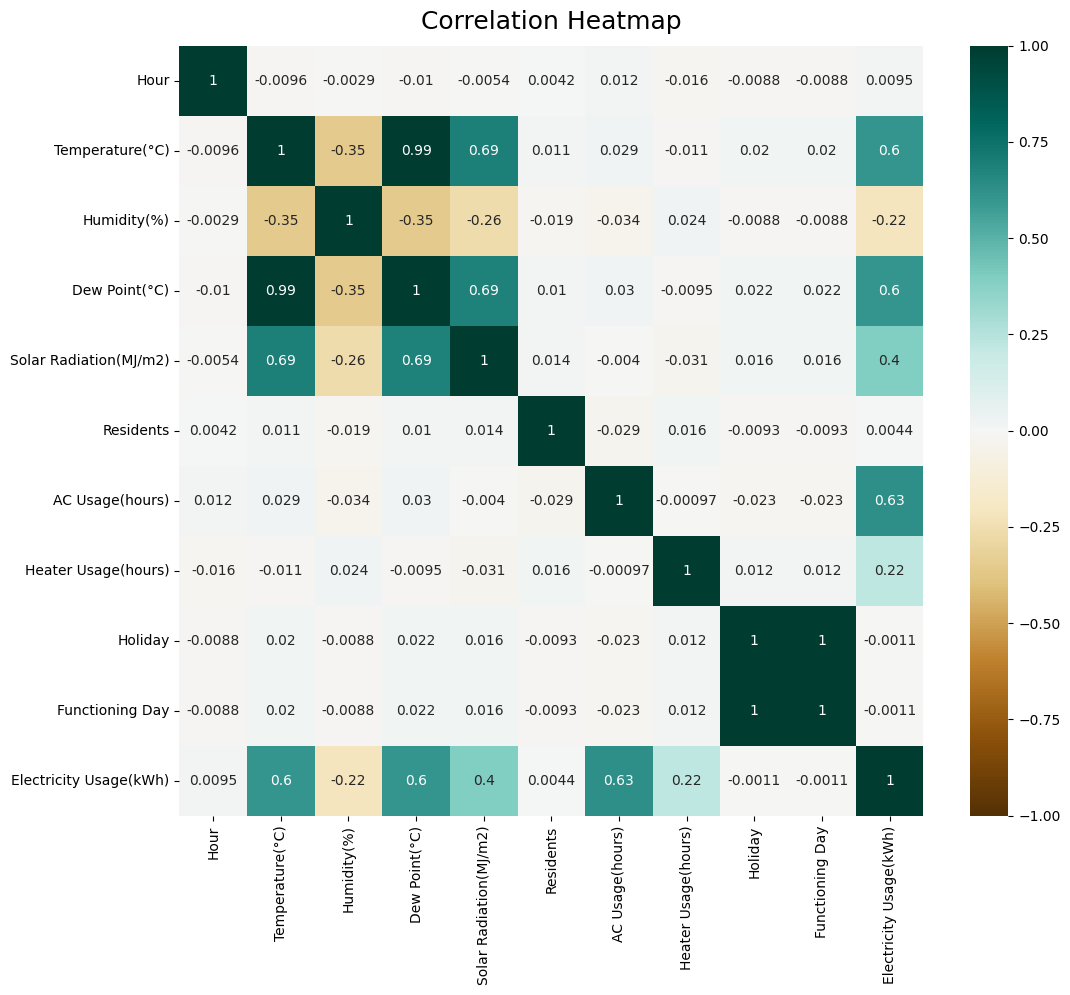

In [63]:
plt.figure(figsize=(12,10))

heatmap = sns.heatmap(electricity[col].corr(), vmin=-1, annot=True, cmap='BrBG')

heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':18}, pad=12)

Based on the correlation heatmap you shared, we can identify some critical points regarding collinearity.
- There is a correlation of 0.99 between Temperature(°C) and Dew Point(°C). If both are included in the regression model, the standard errors will be inflated, and the model will have difficulty determining which variable actually influences Electricity Usage.
- Variables such as Hour, Residents, and Humidity(%) have very low correlation (approaching 0) with other variables. These variables carry unique information and are independent of other variables, so they are good to keep in the model.

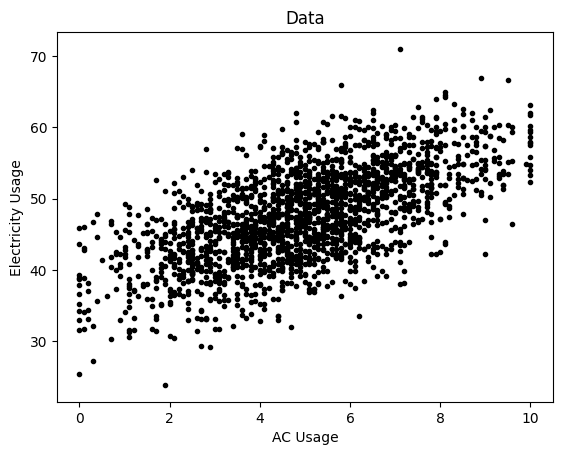

In [64]:
x = electricity['AC Usage(hours)']
y = electricity['Electricity Usage(kWh)']

plt.scatter(x, y, color = 'k', marker='.')

plt.xlabel('AC Usage')
plt.ylabel("Electricity Usage")

# Add a title and adjust the margins
plt.title("Data")

# Show the plot
plt.show()

- From the visualization, we see they have positive correlation

In [65]:
electricity.columns

Index(['Date', 'Hour', 'Season', 'Temperature(°C)', 'Humidity(%)',
       'Dew Point(°C)', 'Solar Radiation(MJ/m2)', 'Residents',
       'AC Usage(hours)', 'Heater Usage(hours)', 'Holiday', 'Functioning Day',
       'Electricity Usage(kWh)'],
      dtype='object')

### Fit Linear Regression

- Rename the colomns to use it in the ols formula

In [66]:
electricity = electricity.rename(columns={'Temperature(°C)':'Temperature','Humidity(%)':'Humidity','Dew Point(°C)':'Dew_Point',
                                          'Solar Radiation(MJ/m2)':'Solar_Radiation','AC Usage(hours)':'AC_Usage',
                                          'Heater Usage(hours)':'Heater_Usage','Functioning Day':'Functioning_Day','Electricity Usage(kWh)':'Electricity_Usage'})

In [67]:
electricity.columns# Create OLS model object
model = smf.ols("Electricity_Usage ~ Temperature", electricity)

# Fit the model
results = model.fit()

# Extract the results (Coefficient and Standard Error) to DataFrame
results_temp = print_coef_std_err(results)

- Visualize the data and the regression line

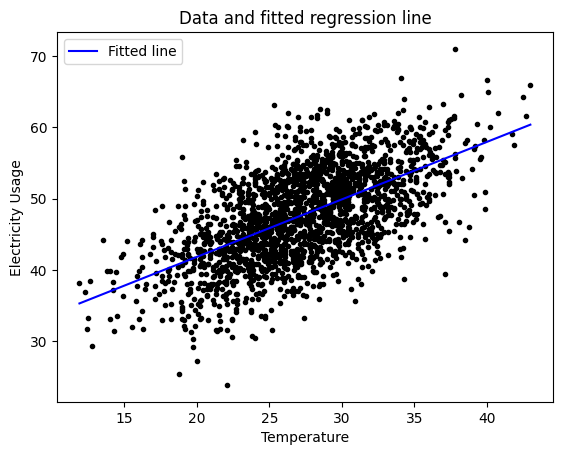

In [68]:
predictor = "Temperature"
outcome = "Electricity_Usage"
data = electricity.copy()
results_ = results_temp.copy()

# Plot the data
plt.scatter(data[predictor], data[outcome], color = "k", marker=".")

# Calculate the fitted values
a_hat = results_.loc["Intercept"]["coef"]
b_hat = results_.loc[predictor]["coef"]

x_domain = np.linspace(np.min(data[predictor]), np.max(data[predictor]), 10000)

fitted_values = a_hat + b_hat * x_domain

# Plot the fitted line
plt.plot(x_domain, fitted_values, label="Fitted line", color = "b")

# Add a legend and labels
plt.legend()
plt.ylabel("Electricity Usage")
plt.xlabel("Temperature")

# Add a title and adjust the margins
plt.title("Data and fitted regression line")

# Show the plot
plt.show()

- Add the Solar_Radiation Predictor

In [69]:
model = smf.ols('Electricity_Usage ~ Temperature + Solar_Radiation', electricity)

results = model.fit()

results_temp_sol = print_coef_std_err(results)

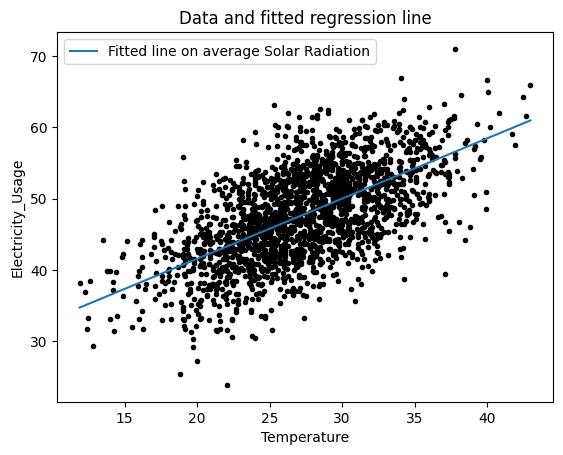

In [70]:
predictors = ["Temperature","Solar_Radiation"]
outcome = "Electricity_Usage"
data = electricity.copy()
results_ = results_temp_sol.copy()
# linestyles = {0 : "--", 1: "-"}
# c = {0 : "b", 1: "g"}
# markers = {0 : "x", 1: "."}

# Plot the data
plt.scatter(data[predictors[0]], data[outcome], color = "k", marker=".")


# x value as mom_iq predictors value
x_domain = np.linspace(np.min(data[predictors[0]]), np.max(data[predictors[0]]), 100)

# Calculate the fitted values for two lines regarding the mom_hs (0 and 1)
beta0_hat = results_.loc["Intercept"]["coef"]
beta1_hat = results_.loc[predictors[0]]["coef"]
beta2_hat = results_.loc[predictors[1]]["coef"]

fitted_values = beta0_hat +  beta1_hat * x_domain  + beta2_hat * data[predictors[1]].mean()

# Plot two fitted line
plt.plot(x_domain, fitted_values, label = f"Fitted line on average Solar Radiation")

# Add a legend and labels
plt.legend()
plt.ylabel(f"{outcome}")
plt.xlabel(f"{predictors[0]}")

# Add a title and adjust the margins
plt.title("Data and fitted regression line")

# Show the plot
plt.show()

- Next, we try the AC_Usage as the comparison

In [71]:
model = smf.ols('Electricity_Usage ~ Temperature + AC_Usage', electricity)

results = model.fit()

results_temp_ac = print_coef_std_err(results)

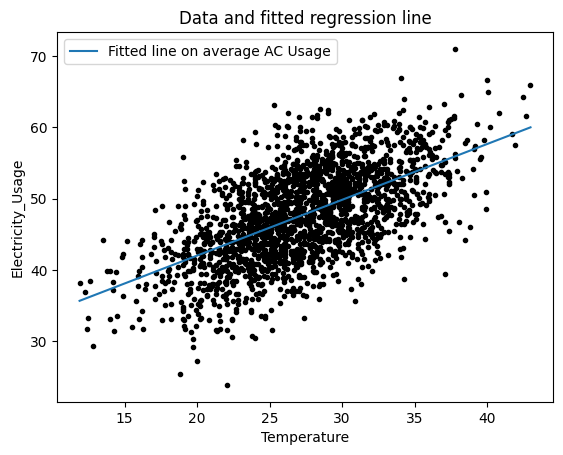

In [72]:
predictors = ["Temperature","AC_Usage"]
outcome = "Electricity_Usage"
data = electricity.copy()
results_ = results_temp_ac.copy()
# linestyles = {0 : "--", 1: "-"}
# c = {0 : "b", 1: "g"}
# markers = {0 : "x", 1: "."}

# Plot the data
plt.scatter(data[predictors[0]], data[outcome], color = "k", marker=".")


# x value as mom_iq predictors value
x_domain = np.linspace(np.min(data[predictors[0]]), np.max(data[predictors[0]]), 100)

# Calculate the fitted values for two lines regarding the mom_hs (0 and 1)
beta0_hat = results_.loc["Intercept"]["coef"]
beta1_hat = results_.loc[predictors[0]]["coef"]
beta2_hat = results_.loc[predictors[1]]["coef"]

fitted_values = beta0_hat +  beta1_hat * x_domain  + beta2_hat * data[predictors[1]].mean()

# Plot two fitted line
plt.plot(x_domain, fitted_values, label = f"Fitted line on average AC Usage")

# Add a legend and labels
plt.legend()
plt.ylabel(f"{outcome}")
plt.xlabel(f"{predictors[0]}")

# Add a title and adjust the margins
plt.title("Data and fitted regression line")

# Show the plot
plt.show()

### Coefficient and Standard Error Comparison 

In [73]:
results_temp

,coef,std err
Intercept,25.736324,0.658819
Temperature,0.805725,0.023768


In [74]:
results_temp_sol

,coef,std err
Intercept,26.468254,0.789674
Temperature,0.843896,0.032879
Solar_Radiation,-0.374339,0.222895


In [75]:
results_temp_ac

,coef,std err
Intercept,16.473983,0.455911
Temperature,0.781899,0.015228
AC_Usage,1.994157,0.037193


- **Temperature and Solar Radiation (Model 2)** :
    - Although these two variables have a fairly strong correlation (0.69), the standard error of the Temperature coefficient increases to 0.0328 compared to the baseline model (0.0237). This indicates that collinearity (although not yet extreme) is beginning to cause uncertainty in the coefficient estimates.
- **Temperature and AC Usage (Model 3)** :
    - Because AC Usage has almost no correlation with Temperature (0.029), this variable provides very clean new information. As a result, the standard error on the Temperature variable actually decreases to 0.0152. This model is much more stable because the two predictors are independent of each other.

- Lets see the visual representation of standdard error on Model 2 and 3

In [76]:
def sampling(data, n_sample):
    """
    Fungsi to do repeatedly sample from the same data
    :param data: <pandas dataframe> sample data
    :param n_sample: <int> number of sample
    :return list_data: <list> set of samples
    """
    list_data = []
    for i in range(n_sample):
        data_sample = data.sample(n = len(data),
                                  replace = True)
        
        list_data.append(data_sample)

    return list_data

Text(0, 0.5, 'Electric Usage')

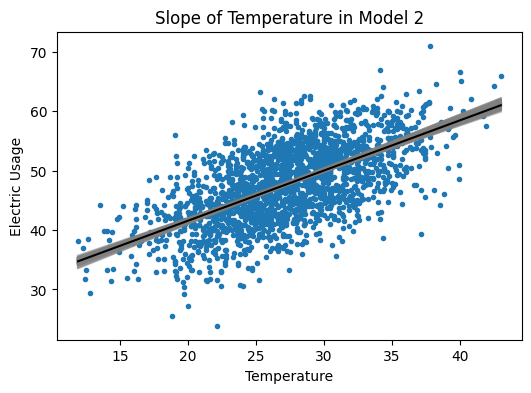

In [78]:
data_ = electricity
x1 = "Temperature"
x2 = "Solar_Radiation"
y = "Electricity_Usage"
n_sample = 100

# Get samples from the same data
list_auto_data = sampling(data = data_,
                          n_sample = n_sample)


# Display each regression line fitted on each sample data

plt.figure(figsize=(6,4))

plt.scatter(data_[x1], data_[y], marker='.')

for i in range(n_sample):
    data_train = list_auto_data[i]

    # Fit model
    model = smf.ols("Electricity_Usage ~ Temperature + Solar_Radiation", data_train)

    results = model.fit()

    # Store the coefficient
    beta_0 = results.params.Intercept
    beta_1 = results.params.Temperature
    beta_2 = results.params.Solar_Radiation
    
    x_1 = np.linspace(data_[x1].min(), data_[x1].max(), 50)
    x_2 = data_[x2].mean()
    
    # Calculate the fitted value
    
    fitted_values = beta_0 + (beta_1 * x_1) + (beta_2 * x_2)

    # Plot the fitted line
    
    plt.plot(x_1, fitted_values, color='grey', alpha = 0.5, zorder=1)

# Fit model on original data
model = smf.ols("Electricity_Usage ~ Temperature + Solar_Radiation", data_)
results = model.fit()

# Store the coefficient
beta_0 = results.params.Intercept
beta_1 = results.params.Temperature
beta_2 = results.params.Solar_Radiation

x_1 = np.linspace(data_[x1].min(), data_[x1].max(), 50)
x_2 = data_[x2].mean()

# Calculate the fitted value
fitted_values = beta_0 + (beta_1 * x_1) + (beta_2 * x_2)

# Plot the fitted line on original data
plt.plot(x_1, fitted_values, color='k', zorder=3)

plt.title("Slope of Temperature in Model 2")
plt.xlabel("Temperature")
plt.ylabel("Electric Usage")

Text(0, 0.5, 'Electricity Usage')

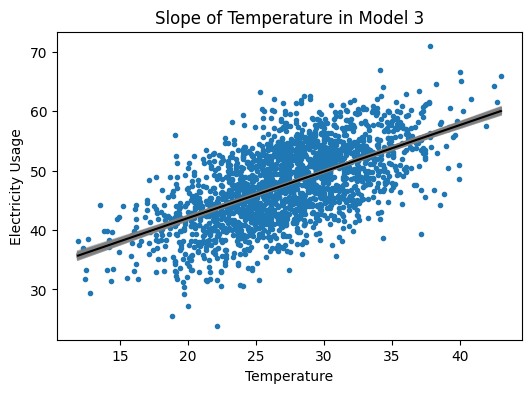

In [80]:
data_ = electricity
x1 = "Temperature"
x2 = "AC_Usage"
y = "Electricity_Usage"
n_sample = 100

# Get samples from the same data
list_auto_data = sampling(data = data_,
                          n_sample = n_sample)


# Display each regression line fitted on each sample data

plt.figure(figsize=(6,4))

plt.scatter(data_[x1], data_[y], marker='.')

for i in range(n_sample):
    data_train = list_auto_data[i]

    # Fit model
    model = smf.ols("Electricity_Usage ~ Temperature + AC_Usage", data_train)

    results = model.fit()

    # Store the coefficient
    beta_0 = results.params.Intercept
    beta_1 = results.params.Temperature
    beta_2 = results.params.AC_Usage
    
    x_1 = np.linspace(data_[x1].min(), data_[x1].max(), 50)
    x_2 = data_[x2].mean()
    
    # Calculate the fitted value
    
    fitted_values = beta_0 + (beta_1 * x_1) + (beta_2 * x_2)

    # Plot the fitted line
    
    plt.plot(x_1, fitted_values, color='grey', alpha = 0.5, zorder=1)

# Fit model on original data
model = smf.ols("Electricity_Usage ~ Temperature + AC_Usage", data_)
results = model.fit()

# Store the coefficient
beta_0 = results.params.Intercept
beta_1 = results.params.Temperature
beta_2 = results.params.AC_Usage

x_1 = np.linspace(data_[x1].min(), data_[x1].max(), 50)
x_2 = data_[x2].mean()

# Calculate the fitted value
fitted_values = beta_0 + (beta_1 * x_1) + (beta_2 * x_2)

# Plot the fitted line on original data
plt.plot(x_1, fitted_values, color='k', zorder=3)

plt.title("Slope of Temperature in Model 3")
plt.xlabel("Temperature")
plt.ylabel("Electricity Usage")

This is an example of multicollinearity in a variable.

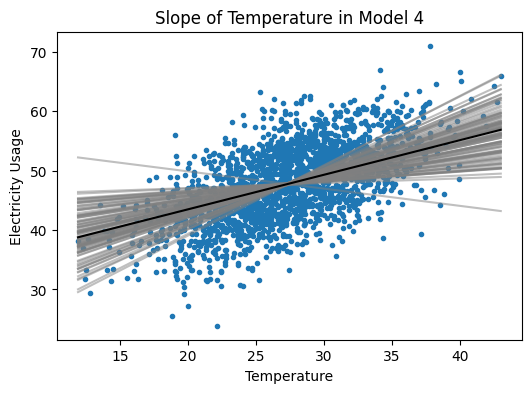

In [89]:
data_ = electricity
x1 = 'Temperature'
x2 = 'Dew_Point'
y = 'Electricity_Usage'
n_sample = 100

# Get samples from the same data
list_auto_data = sampling(data=data_, n_sample=n_sample)

plt.figure(figsize=(6,4))
plt.scatter(data_[x1], data_[y], marker='.')

for i in range(n_sample):
    data_train = list_auto_data[i]

    # Fit model
    model = smf.ols('Electricity_Usage ~ Temperature + Dew_Point', data_train)
    results = model.fit()

    # Store the coefficient
    beta_0 = results.params.Intercept
    beta_1 = results.params.Temperature
    beta_2 = results.params.Dew_Point

    x_1 = np.linspace(data_[x1].min(), data_[x1].max(), 50)
    x_2 = data_[x2].mean()

    fitted_values = beta_0 + (beta_1 * x_1) + (beta_2 * x_2)
    plt.plot(x_1, fitted_values, color='grey', alpha=0.5, zorder=1)

# Fit model on original data
model = smf.ols('Electricity_Usage ~ Temperature + Dew_Point', data_)
results = model.fit()

beta_0 = results.params.Intercept
beta_1 = results.params.Temperature
beta_2 = results.params.Dew_Point

x_1 = np.linspace(data_[x1].min(), data_[x1].max(), 50)
x_2 = data_[x2].mean()

fitted_values = beta_0 + (beta_1 * x_1) + (beta_2 * x_2)
plt.plot(x_1, fitted_values, color='k', zorder=3)

plt.title('Slope of Temperature in Model 4')
plt.xlabel('Temperature')
plt.ylabel('Electricity Usage')
plt.show()


In [92]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Pilih variabel independen
X = data_[["Temperature", "AC_Usage", "Solar_Radiation", "Dew_Point"]]
X['intercept'] = 1 # Statsmodels need intercept

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

          Variable        VIF
0      Temperature  96.659197
1         AC_Usage   1.002145
2  Solar_Radiation   1.919499
3        Dew_Point  95.140094
4        intercept  66.700543


C:\Users\HP Victus\AppData\Local\Temp\ipykernel_19504\2958992436.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['intercept'] = 1 # Statsmodels need intercept


- From the visualization we see that the shadow around the line shows the result of regression line after repeatedly fit on the same data
- The model 2 (Use Temperature and Solar Radiation) have slighly wider shadow around the line since it has higher standard eror than Model 3 (Use Temperature and AC Usage)
- The model 4 (Use Temperature and Dew Point) shows very extreme multicollinearity. Including this variable will cause extreme multicollinearity that will ruin your model. we have to remove one of these variables because they carry exactly the same information